In [209]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
import pydicom
import cv2
import seaborn as sns
import nibabel as nib
import ast
# from utils import get_file_path,header_consistency_check, view_single, view_all, cal_mask_volume
from utils import *
from constants import DATASET_DIR, HEADER_PATH, LABEL_FILE_NAME, CT_SCANS_FODLER, MASKS_FOLDER

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [210]:
path = DATASET_DIR
files = os.listdir(path)
print(files)

['ct_ich.yml', 'ct_scans', 'hemorrhage_diagnosis_raw_ct.csv', 'LICENSE.txt', 'masks', 'Patient_demographics.csv', 'Read_me.txt', 'SHA256SUMS.txt', 'split_raw_data.py']


In [211]:
data = []

for f in files:
    full_path = os.path.join(path, f)
    
    if os.path.isfile(full_path):
        size = os.path.getsize(full_path)  # bytes
        ext = os.path.splitext(f)[1]
        
        data.append({
            "File Name": f,
            "Extension": ext,
            "Size (KB)": round(size / 1024, 2)
        })

df = pd.DataFrame(data)

df.head(20)

,File Name,Extension,Size (KB)
0,ct_ich.yml,.yml,0.74
1,hemorrhage_diagnosis_raw_ct.csv,.csv,58.27
2,LICENSE.txt,.txt,2.29
3,Patient_demographics.csv,.csv,1.99
4,Read_me.txt,.txt,3.41
5,SHA256SUMS.txt,.txt,12.28
6,split_raw_data.py,.py,2.88


In [212]:
ct_path = os.path.join(path, "ct_scans")
ct_folder = os.listdir(ct_path)
print(ct_folder)

['049.nii', '050.nii', '051.nii', '052.nii', '053.nii', '054.nii', '055.nii', '056.nii', '057.nii', '058.nii', '066.nii', '067.nii', '068.nii', '069.nii', '070.nii', '071.nii', '072.nii', '073.nii', '074.nii', '075.nii', '076.nii', '077.nii', '078.nii', '079.nii', '080.nii', '081.nii', '082.nii', '083.nii', '084.nii', '085.nii', '086.nii', '087.nii', '088.nii', '089.nii', '090.nii', '091.nii', '092.nii', '093.nii', '094.nii', '095.nii', '096.nii', '097.nii', '098.nii', '099.nii', '100.nii', '101.nii', '102.nii', '103.nii', '104.nii', '105.nii', '106.nii', '107.nii', '108.nii', '109.nii', '110.nii', '111.nii', '112.nii', '113.nii', '114.nii', '115.nii', '116.nii', '117.nii', '118.nii', '119.nii', '120.nii', '121.nii', '122.nii', '123.nii', '124.nii', '125.nii', '126.nii', '127.nii', '128.nii', '129.nii', '130.nii']


In [213]:
len(ct_folder)

75

In [214]:
mask_path = os.path.join(path, "masks")
mask_folder = os.listdir(mask_path)
print(mask_folder)

['049.nii', '050.nii', '051.nii', '052.nii', '053.nii', '054.nii', '055.nii', '056.nii', '057.nii', '058.nii', '066.nii', '067.nii', '068.nii', '069.nii', '070.nii', '071.nii', '072.nii', '073.nii', '074.nii', '075.nii', '076.nii', '077.nii', '078.nii', '079.nii', '080.nii', '081.nii', '082.nii', '083.nii', '084.nii', '085.nii', '086.nii', '087.nii', '088.nii', '089.nii', '090.nii', '091.nii', '092.nii', '093.nii', '094.nii', '095.nii', '096.nii', '097.nii', '098.nii', '099.nii', '100.nii', '101.nii', '102.nii', '103.nii', '104.nii', '105.nii', '106.nii', '107.nii', '108.nii', '109.nii', '110.nii', '111.nii', '112.nii', '113.nii', '114.nii', '115.nii', '116.nii', '117.nii', '118.nii', '119.nii', '120.nii', '121.nii', '122.nii', '123.nii', '124.nii', '125.nii', '126.nii', '127.nii', '128.nii', '129.nii', '130.nii']


In [215]:
len(mask_folder)

75

In [216]:
file_path = os.path.join(ct_path, "049.nii")
nii_img = nib.load(file_path)
data = nii_img.get_fdata()
# print("Shape:", data.shape)
# print("Data type:", data.dtype)
header = nii_img.header
print(header)

<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : np.bytes_(b'')
db_name         : np.bytes_(b'')
extents         : 16384
session_error   : 0
regular         : np.bytes_(b'r')
dim_info        : 48
dim             : [  3 512 512  39   1   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : int16
bitpix          : 16
slice_start     : 0
pixdim          : [-1.          0.41210938  0.41210938  5.          0.          0.
  0.          0.        ]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 2
cal_max         : 0.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 2914
glmin           : -1024
descrip         : np.bytes_(b'time=--------------.---;')
aux_file        : np.bytes_(b';SIEMENS;Head_SAFIRE')
qform_code      : scanner
sform_code      : scanner
quatern_b   

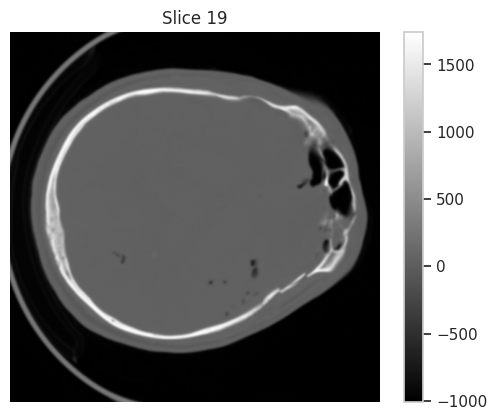

In [217]:
slice_index = data.shape[2] // 2

plt.imshow(data[:, :, slice_index], cmap="gray")
plt.title(f"Slice {slice_index}")
plt.colorbar()
plt.axis("off")
plt.show()

In [218]:
header_consistency_check(ct_path)

All files have identical header keys.


In [219]:
df = pd.read_csv(HEADER_PATH)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 75 entries, 0 to 74
Data columns (total 44 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   patient_id      75 non-null     int64  
 1   sizeof_hdr      75 non-null     int64  
 2   data_type       0 non-null      float64
 3   db_name         0 non-null      float64
 4   extents         75 non-null     int64  
 5   session_error   75 non-null     int64  
 6   regular         75 non-null     str    
 7   dim_info        75 non-null     int64  
 8   dim             75 non-null     str    
 9   intent_p1       75 non-null     float64
 10  intent_p2       75 non-null     float64
 11  intent_p3       75 non-null     float64
 12  intent_code     75 non-null     int64  
 13  datatype        75 non-null     int64  
 14  bitpix          75 non-null     int64  
 15  slice_start     75 non-null     int64  
 16  pixdim          75 non-null     str    
 17  vox_offset      75 non-null     float64
 18  scl

### Header explain
#### Header keys
---
- sizeof_hdr: size of header, always (348 bytes)
- magic:
    - n+1: single .nii (header + data)
    - ni1: double file (.hdr + .img)
- data_tpye: list data tpye
- db_name: name of old database
- extents: size of old file
- session_error:
- regular: 

#### Image Dimension
---
- dim_info:
- dim: dimension of
- intent_1,  intent_2, intent_3
- intent_code
- datatype: voxel's data type
- bitpix: bit/voxel
- slice_start: First slice index
- pixdim: voxel spacing
- vox_offset: 
- scl_slope, scl_inter: scaling
- slic_code:
- xyzt_units:
- cal_max, cal_min: display range
- slice_duration: slice timing
- toffset: time offset
- glmax, glmin: global max/min
- descrip: description
- aux_file: auxiliary file

#### Spatial Transformation
---
- qform_code, sform_code: transform code
    - 0 = uknown
    - 1 = Scanner Anat
    - 2 = Aligned Anat
    - 3 = Talairach
    - 4 = MNI152
- quatern_b, quatern_c, quatern_d: quaternion params
- qoffset_x, qoffset_y, qoffset_z: quaternion offset
- srow_x, srow_y, srow_z: 4×4 affine matrix rows
- intent_name: intent description text

In [220]:
df.nunique()

patient_id        75
sizeof_hdr         1
data_type          0
db_name            0
extents            1
session_error      1
regular            1
dim_info           1
dim               19
intent_p1          1
intent_p2          1
intent_p3          1
intent_code        1
datatype           1
bitpix             1
slice_start        1
pixdim            35
vox_offset         1
scl_slope          0
scl_inter          0
slice_end          1
slice_code         1
xyzt_units         1
cal_max            1
cal_min            1
slice_duration     1
toffset            1
glmax             63
glmin              9
descrip            1
aux_file           3
qform_code         1
sform_code         1
quatern_b          1
quatern_c          2
quatern_d          2
qoffset_x         36
qoffset_y         75
qoffset_z         68
srow_x            36
srow_y            75
srow_z            68
intent_name        0
magic              1
dtype: int64

In [221]:
drop_cols =['sizeof_hdr', 'data_type','db_name', 'extents', 'session_error', 'regular', 'dim_info', 'intent_p1', 'intent_p2', 'intent_p3', 'intent_code', 'datatype', 'bitpix', 'slice_start', 'vox_offset', 'scl_slope', 'scl_inter', 'slice_end', 'slice_code', 'xyzt_units', 'cal_max', 'cal_min', 'slice_duration', 'toffset', 'descrip', 'qform_code', 'sform_code', 'intent_name', 'magic']
df_drop = df.drop(columns=drop_cols)
df_drop.head()

,patient_id,dim,pixdim,glmax,glmin,aux_file,quatern_b,quatern_c,quatern_d,qoffset_x,qoffset_y,qoffset_z,srow_x,srow_y,srow_z
0,49,"[3, 512, 512, 39, 1, 1, 1, 1]","[-1.0, 0.412109375, 0.412109375, 5.0, 0.0, 0.0...",2914,-1024,;SIEMENS;Head_SAFIRE,-0.0,1.0,-0.0,105.293945,23.706055,-690.5,"[-0.412109375, -0.0, 0.0, 105.2939453125]","[-0.0, 0.412109375, 0.0, 23.7060546875]","[0.0, -0.0, 5.0, -690.5]"
1,50,"[3, 512, 512, 32, 1, 1, 1, 1]","[-1.0, 0.3515625, 0.3515625, 5.0, 0.0, 0.0, 0....",1943,-1021,;SIEMENS;Head_SAFIRE,-0.0,1.0,-0.0,89.824219,31.675781,-739.0,"[-0.3515625, -0.0, 0.0, 89.82421875]","[-0.0, 0.3515625, 0.0, 31.67578125]","[0.0, -0.0, 5.0, -739.0]"
2,51,"[3, 512, 512, 46, 1, 1, 1, 1]","[-1.0, 0.412109375, 0.412109375, 5.0, 0.0, 0.0...",3046,-1014,;SIEMENS;Head_SAFIRE,-0.0,1.0,-0.0,105.293945,26.706055,-740.0,"[-0.412109375, -0.0, 0.0, 105.2939453125]","[-0.0, 0.412109375, 0.0, 26.7060546875]","[0.0, -0.0, 5.0, -740.0]"
3,52,"[3, 512, 512, 35, 1, 1, 1, 1]","[-1.0, 0.390625, 0.390625, 5.0, 0.0, 0.0, 0.0,...",3071,-1018,;SIEMENS;Head_SAFIRE,-0.0,1.0,-0.0,99.804688,77.195312,-464.5,"[-0.390625, -0.0, 0.0, 99.8046875]","[-0.0, 0.390625, 0.0, 77.1953125]","[0.0, -0.0, 5.0, -464.5]"
4,53,"[3, 512, 512, 35, 1, 1, 1, 1]","[-1.0, 0.47265625, 0.47265625, 5.0, 0.0, 0.0, ...",2806,-1024,;SIEMENS;HeadRoutine,-0.0,1.0,-0.0,120.763672,47.236328,-512.5,"[-0.47265625, -0.0, 0.0, 120.763671875]","[-0.0, 0.47265625, 0.0, 47.236328125]","[0.0, -0.0, 5.0, -512.5]"


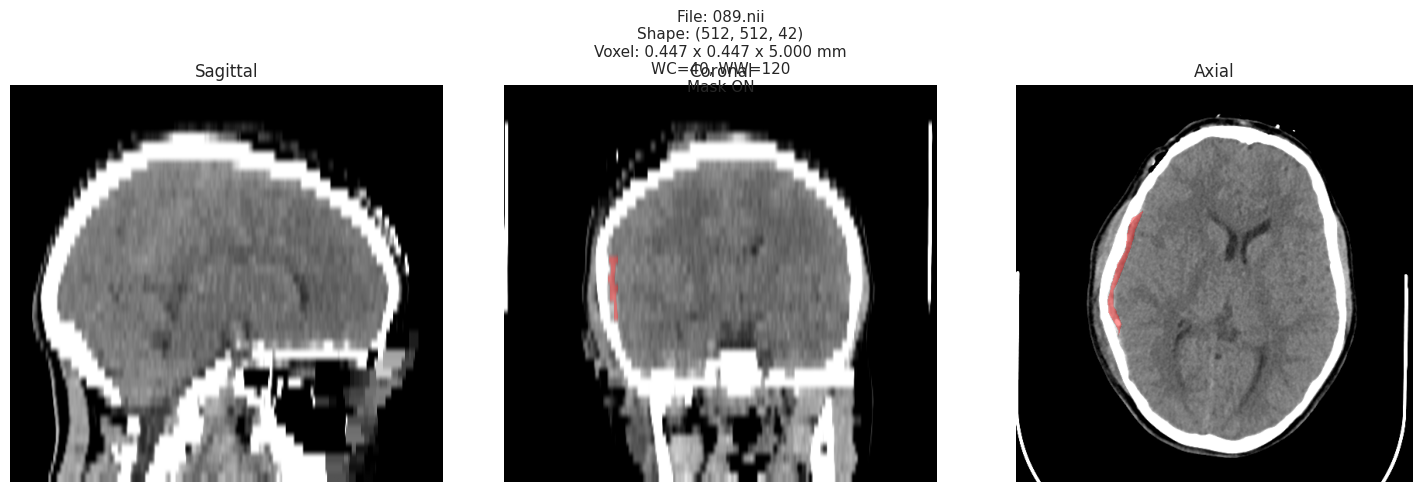

In [237]:
view_single('89', (40, 120), overlay=True)

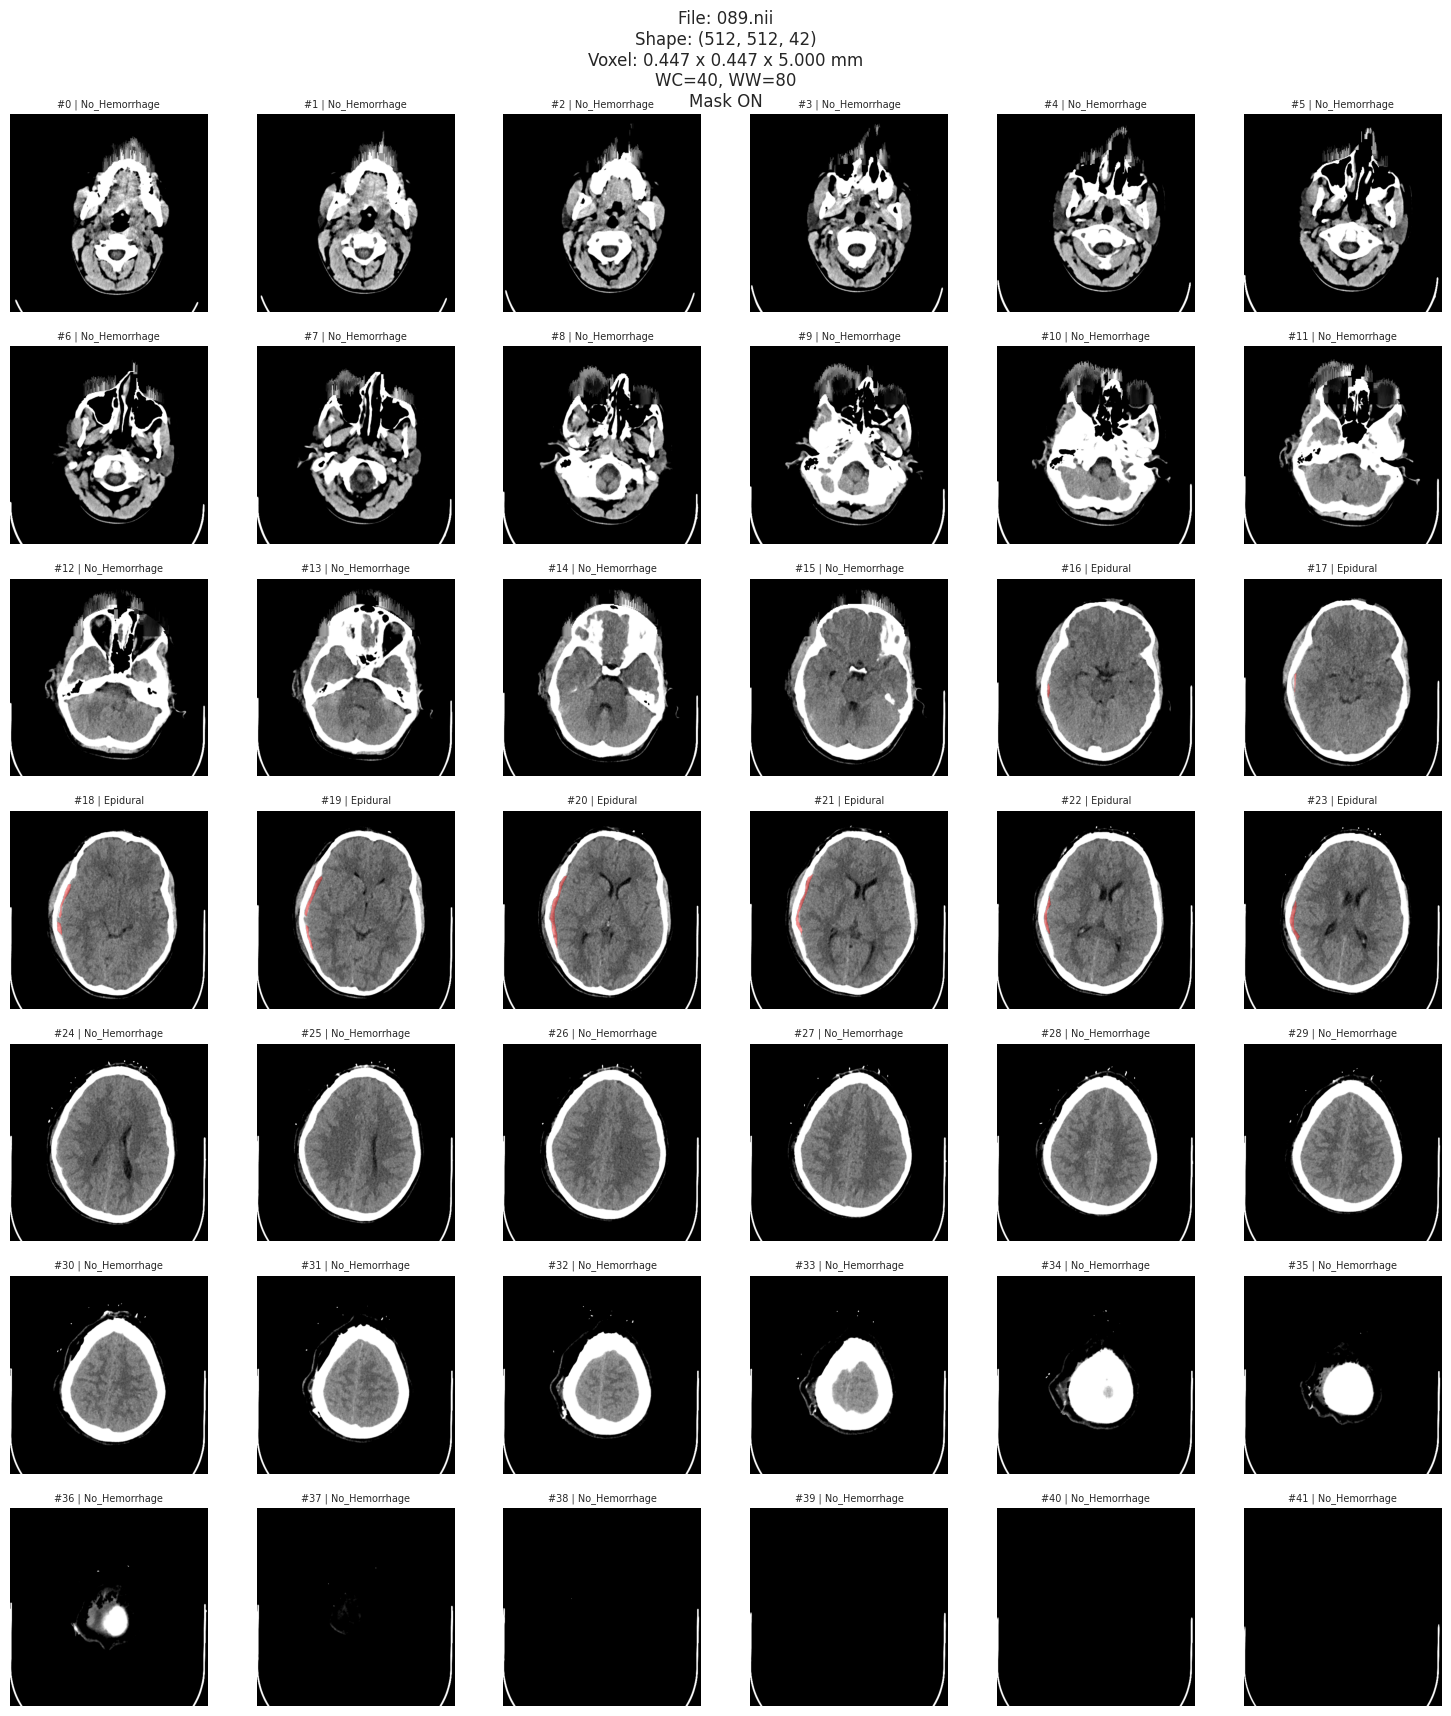

In [238]:
view_all("89", (40, 80), overlay=True)

Text(0.5, 1.0, 'Distribution of Slices per Scan')

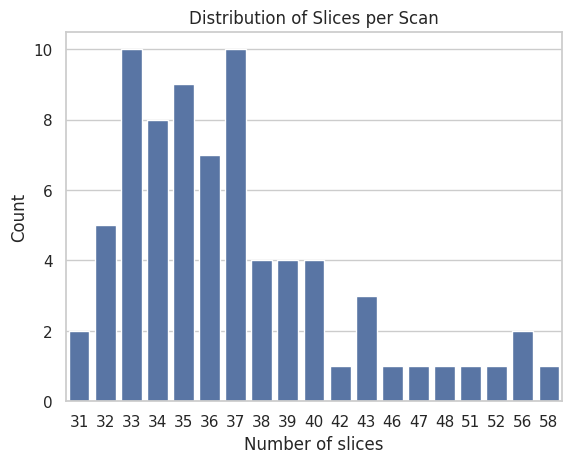

In [224]:
num_slices = df_drop['dim'].apply(ast.literal_eval).apply(lambda x: x[3]).value_counts().sort_index()

plt.figure()
sns.barplot(
    x=num_slices.index,
    y=num_slices.values
)

plt.xlabel("Number of slices")
plt.ylabel("Count")
plt.title("Distribution of Slices per Scan")

In [225]:
df_label = pd.read_csv(os.path.join(DATASET_DIR, LABEL_FILE_NAME))
check = df_label.groupby('PatientNumber')['SliceNumber'].apply(
    lambda x: sorted(x) == list(range(min(x), max(x)+1))
)
check.value_counts()

SliceNumber
True    75
Name: count, dtype: int64

##### No patient have missing slices

In [226]:
subtypes = [
    "Intraventricular",
    "Intraparenchymal",
    "Subarachnoid",
    "Epidural",
    "Subdural"
]

df_long = df_label.melt(
    id_vars=["PatientNumber", "SliceNumber"],
    value_vars=subtypes,
    var_name="Subtype",
    value_name="Presence"
)

# Chỉ giữ slice có hemorrhage subtype
df_long = df_long[df_long["Presence"] == 1]

/tmp/ipykernel_143112/2128395709.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(


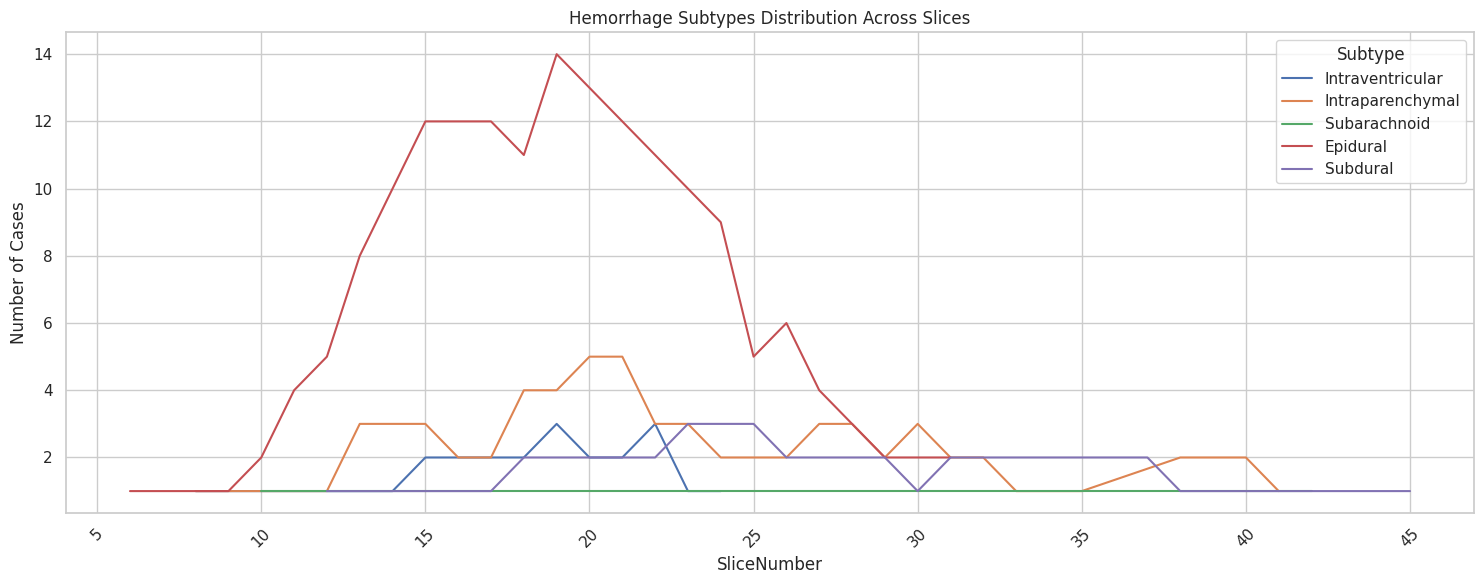

In [227]:
plt.figure(figsize=(15,6))

sns.lineplot(
    data=df_long,
    x="SliceNumber",
    y="Presence",
    hue="Subtype",
    estimator="sum",
    ci=None
)

plt.xticks(rotation=45)

plt.title("Hemorrhage Subtypes Distribution Across Slices")
plt.ylabel("Number of Cases")

plt.tight_layout()
plt.show()

In [228]:
df_label["SlicePercent"] = (
    df_label["SliceNumber"] /
    df_label.groupby("PatientNumber")["SliceNumber"].transform("max")
)

In [229]:
subtypes = [
    "Intraventricular",
    "Intraparenchymal",
    "Subarachnoid",
    "Epidural",
    "Subdural"
]

df_long = df_label.melt(
    id_vars=["PatientNumber", "SliceNumber", "SlicePercent"],
    value_vars=subtypes,
    var_name="Subtype",
    value_name="Presence"
)

df_long = df_long[df_long["Presence"] == 1]

/tmp/ipykernel_143112/504291421.py:9: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(


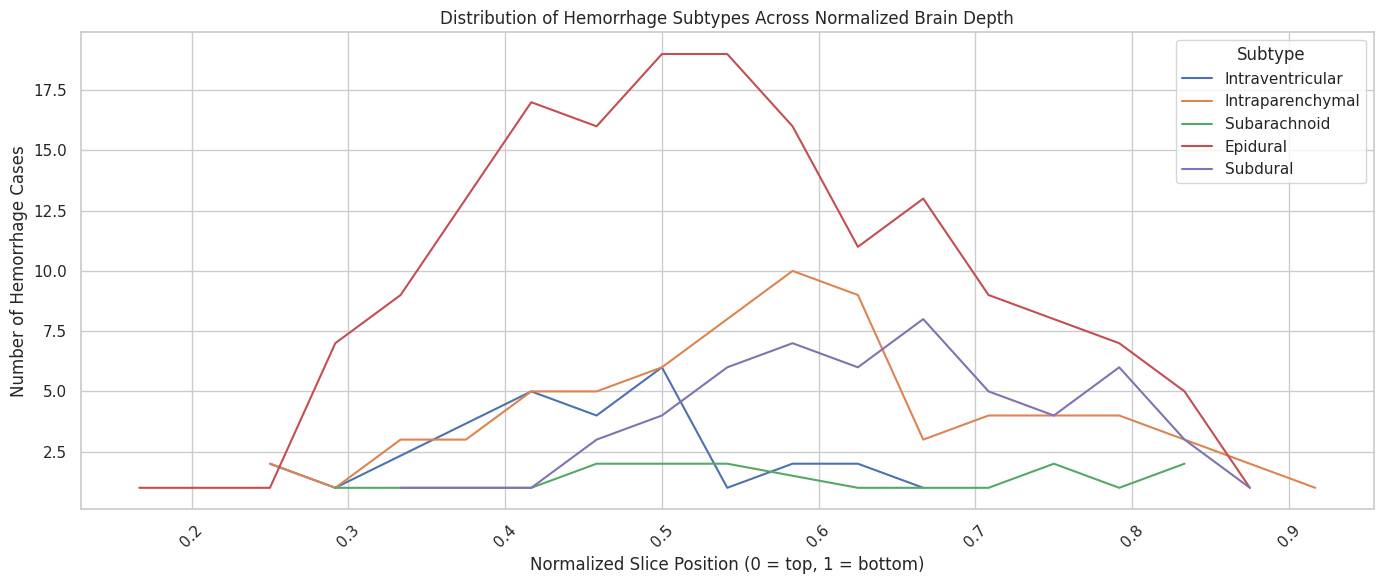

In [230]:
df_long["SliceBin"] = pd.cut(
    df_long["SlicePercent"],
    bins=np.linspace(0, 1, 26),
    labels=np.linspace(0, 1, 25)
)

plt.figure(figsize=(14,6))

sns.lineplot(
    data=df_long,
    x="SliceBin",
    y="Presence",
    hue="Subtype",
    estimator="count",
    ci=None
)

plt.xticks(rotation=45)
plt.xlabel("Normalized Slice Position (0 = top, 1 = bottom)")
plt.ylabel("Number of Hemorrhage Cases")
plt.title("Distribution of Hemorrhage Subtypes Across Normalized Brain Depth")

plt.tight_layout()
plt.show()

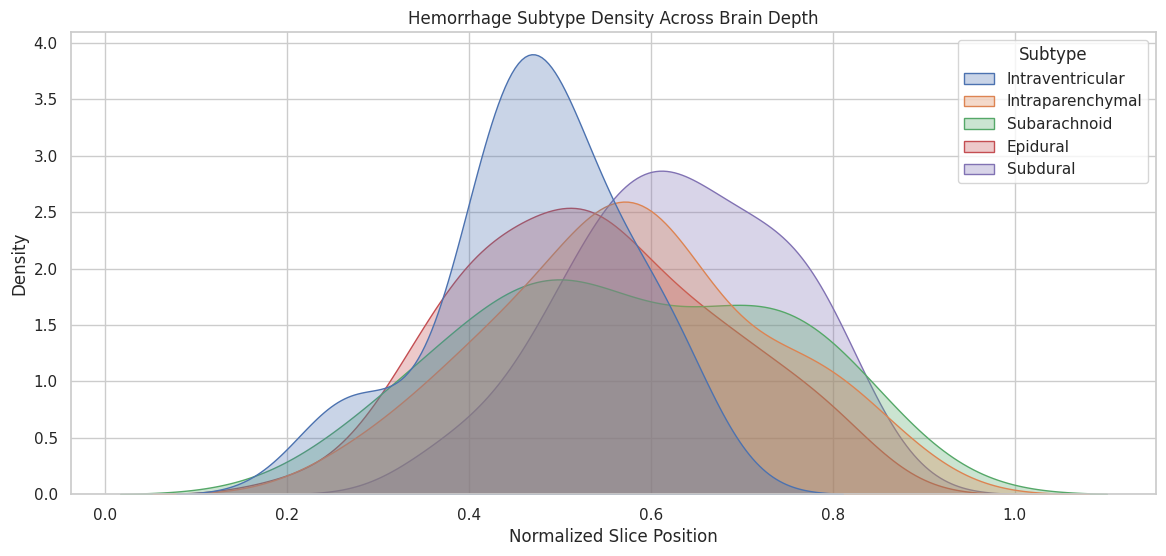

In [231]:
plt.figure(figsize=(14,6))

sns.kdeplot(
    data=df_long,
    x="SlicePercent",
    hue="Subtype",
    fill=True,
    common_norm=False,
    alpha=0.3
)

plt.xlabel("Normalized Slice Position")
plt.title("Hemorrhage Subtype Density Across Brain Depth")

plt.show()

In [232]:
mask_path = get_file_path("077.nii", subfolder="masks")
mask_data, zooms = load_nifti(mask_path)

_, vol_ml = cal_mask_volume(mask_data, zooms)

# print("Volume: ", vol_mm3, "(mm³)")
print("Volume: ", vol_ml, "(ml)")

Volume:  24.71502685546875 (ml)


In [ ]:
df_volume = build_volume_dataframe(DATASET_DIR) 
df_volume.head()

,PatientNumber,MaskVolume_ml
0,49,5.246176
1,50,4.370979
2,51,32.834883
3,52,5.140686
4,53,7.646000


Text(0, 0.5, 'Count')

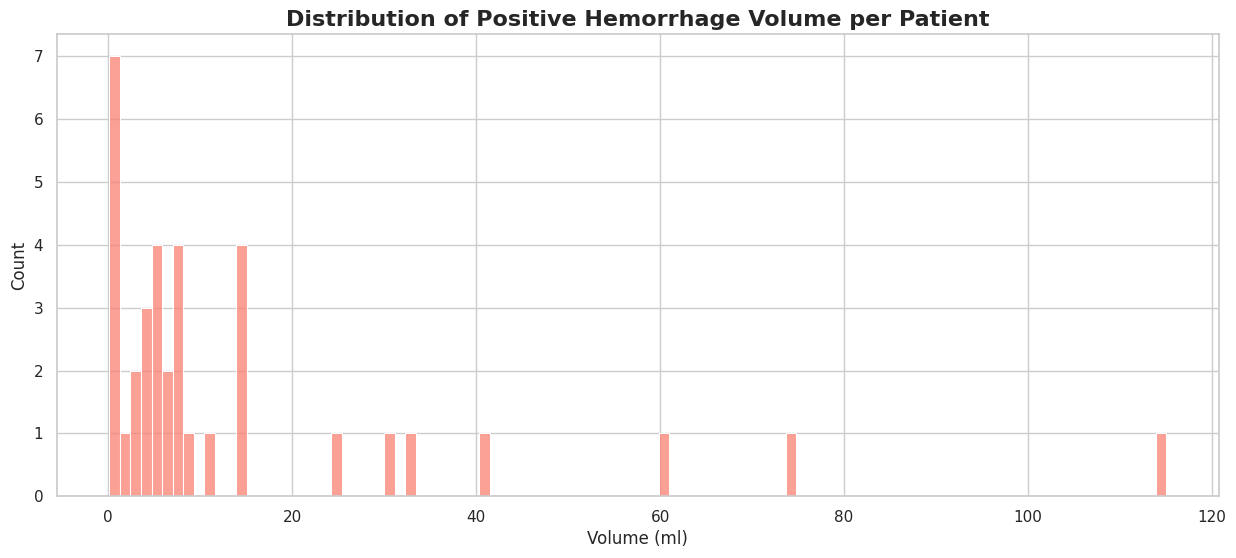

In [235]:
df_filtered = df_volume[df_volume["MaskVolume_ml"] > 0]

sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 6))

ax = sns.histplot(df_filtered["MaskVolume_ml"], kde=False, color="salmon", bins=100)

plt.title("Distribution of Positive Hemorrhage Volume per Patient", fontsize=16, fontweight='bold')
plt.xlabel("Volume (ml)", fontsize=12)
plt.ylabel("Count", fontsize=12)

# mean_val = df_filtered["MaskVolume_ml"].mean()
# median_val = df_filtered["MaskVolume_ml"].median()

# plt.axvline(mean_val, color='blue', linestyle='--', label=f'Mean: {mean_val:.2f}')
# plt.axvline(median_val, color='green', linestyle='-', label=f'Median: {median_val:.2f}')

# plt.legend()